In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report

In [14]:
print("Loading Fashion MNIST dataset......")
X,y=fetch_openml(
    'Fashion-MNIST',
    version=1,
    return_X_y=True,
    as_frame=False
)
X=X.astype('float32')
y=y.astype('int')
print("Dataset shape",X.shape)


Loading Fashion MNIST dataset......
Dataset shape (70000, 784)


In [15]:
X=X[:10000]
y=y[:10000]
X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training samples:",X_train.shape[0])
print("Testing sample:",X_test.shape[0])

Training samples: 8000
Testing sample: 2000


In [16]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)



In [7]:
print("\nTraining Linear SVM...")
linear_svm=SVC(kernel='linear')
linear_svm.fit(X_train,y_train)
y_pred_linear=linear_svm.predict(X_test)
linear_accuracy=accuracy_score(y_test,y_pred_linear)
print("Linear SVM Accuracy:",linear_accuracy*100,"%")


Training Linear SVM...
Linear SVM Accuracy: 81.6 %


In [9]:
print("\nTraining RBF SVM...")
rbf_svm=SVC(
    kernel='rbf',
    gamma='scale'
)
rbf_svm.fit(X_train,y_train)
y_pred_rbf=rbf_svm.predict(X_test)
rbf_accuracy=accuracy_score(y_test,y_pred_rbf)
print("RBF SVM Accuracy:",rbf_accuracy*100,"%")


Training RBF SVM...
RBF SVM Accuracy: 84.6 %


In [17]:
print("\n---Linear SVM Classifion Report---")
print(classification_report(y_test,y_pred_linear))
print("\n---RBF SVM Classification Report---")
print(classification_report(y_test,y_pred_rbf))


---Linear SVM Classifion Report---
              precision    recall  f1-score   support

           0       0.71      0.84      0.77       189
           1       0.95      0.97      0.96       205
           2       0.63      0.75      0.68       203
           3       0.82      0.81      0.81       204
           4       0.69      0.61      0.65       195
           5       0.91      0.93      0.92       198
           6       0.66      0.51      0.57       204
           7       0.90      0.89      0.89       204
           8       0.97      0.93      0.95       198
           9       0.92      0.92      0.92       200

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.81      2000
weighted avg       0.82      0.82      0.81      2000


---RBF SVM Classification Report---
              precision    recall  f1-score   support

           0       0.75      0.81      0.78       189
           1       0.99      0.95      0.97       205
     

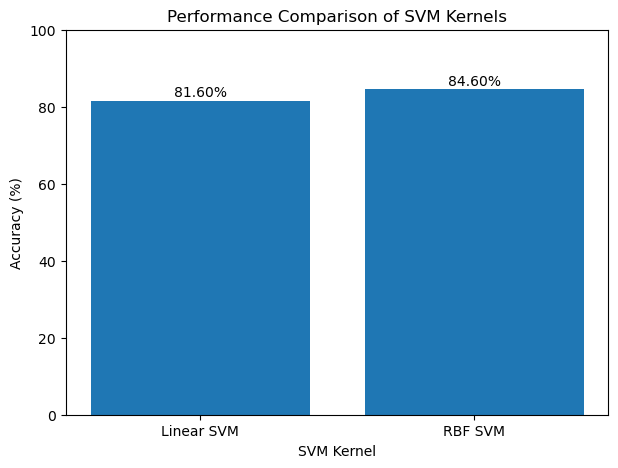

In [18]:
models=['Linear SVM','RBF SVM']
accuracy=[linear_accuracy*100,rbf_accuracy*100]
plt.figure(figsize=(7,5))
bars=plt.bar(models,accuracy)
plt.ylabel("Accuracy (%)")
plt.xlabel("SVM Kernel")
plt.title("Performance Comparison of SVM Kernels")
plt.ylim(0,100)
for bar,value in zip(bars,accuracy):
    plt.text(
        bar.get_x()+bar.get_width()/2,
        value+1,
        f"{value:.2f}%",
        ha='center'
    )
plt.show()